# Unified Engine & Training Pipeline Playground
**Scope**: Unified HeteroGNN training, validation, and submission assembly  

This notebook covers:
1. **Data Pipeline Verification** — Load events, build unified graphs, inspect dimensions
2. **Model Smoke Test** — Forward pass through `UnifiedFloodModel`
3. **Loss Function Verification** — `FloodLoss` with variance-weighted SRMSE
4. **Training Pipeline** — Full training with curriculum learning
5. **Validation** — Leave-One-Event-Out with hierarchical SRMSE
6. **Training Curve Visualisation** — Loss, SRMSE, LR, TF ratio
7. **Submission Generation** — End-to-end inference pipeline

In [1]:
# ── Cell 1: Imports & Setup ─────────────────────────────────────────
import sys
import os
import warnings
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Ensure project root (parent of experiments/) is on the path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Set data path BEFORE importing src.config (which reads it at import time)
os.environ.setdefault("FLOOD_DATA_PATH", str(PROJECT_ROOT / "data"))

# Core imports (src.config reads FLOOD_DATA_PATH on first import)
from src.config import RAW_DATA_PATH, MODELS_DIR, PROJECT_ROOT as PROJ_ROOT
from src.dataset import FloodDataset
from src.graph_builder_unified import (
    build_hetero_graph,
    get_feature_dims,
    summarise_graph,
)
from src.model_unified import UnifiedHeteroModel
from src.loss import (
    FloodLoss,
    standardized_rmse_loss,
    standardized_rmse_metric,
    SRMSEAccumulator,
    per_node_loss_breakdown,
)

# Device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data path    : {RAW_DATA_PATH}")
print(f"MODELS_DIR   : {MODELS_DIR}  (exists={MODELS_DIR.is_dir()})")
print(f"Device       : {DEVICE}")
print(f"PyTorch      : {torch.__version__}")

c:\Users\Jian Wen Lee\UrbanFloodBench\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root : C:\Users\Jian Wen Lee\UrbanFloodBench
Data path    : C:\Users\Jian Wen Lee\UrbanFloodBench\data
MODELS_DIR   : C:\Users\Jian Wen Lee\UrbanFloodBench\data\Models  (exists=True)
Device       : cuda
PyTorch      : 2.6.0+cu124


## 1. Data Pipeline Verification

Load the dataset, verify static caching, and build a unified graph.

In [2]:
# ── Cell 2: Load Dataset & Inspect ──────────────────────────────────
ds = FloodDataset(str(RAW_DATA_PATH), mode="train")
print(f"\nTotal events: {len(ds)}")
print(f"Models: {ds.get_model_ids()}")

for mid in ds.get_model_ids():
    events = ds.get_event_ids(mid)
    print(f"  Model_{mid}: {len(events)} events")

# Grab a sample event
sample = ds[0]
print(f"\nSample event: Model_{sample['model_id']}, Event_{sample['event_id']}")
print(f"  1D nodes static shape: {sample['static_1d_nodes'].shape}")
print(f"  2D nodes static shape: {sample['static_2d_nodes'].shape}")
print(f"  1D dynamic shape: {sample['dynamic_1d_nodes'].shape}")
print(f"  2D dynamic shape: {sample['dynamic_2d_nodes'].shape}")

# Verify static caching: load same model twice
_ = ds[0]  # First load
_ = ds[0]  # Should hit cache
print(f"\nStatic cache populated for models: {list(ds.static_cache.keys())}")

FloodDataset (train) — 137 events across 2 model(s):
  Model_1: 68 events
  Model_2: 69 events

Total events: 137
Models: ['1', '2']
  Model_1: 68 events
  Model_2: 69 events

Sample event: Model_1, Event_1
  1D nodes static shape: (17, 7)
  2D nodes static shape: (3716, 10)
  1D dynamic shape: (1598, 4)
  2D dynamic shape: (349304, 5)

Static cache populated for models: ['1']


In [3]:
# ── Cell 3: Build Unified Graph ─────────────────────────────────────
graph = build_unified_graph(sample)
print(summarise_graph(graph))

dims = get_feature_dims(graph)
print(f"\nFeature dimensions:")
for k, v in dims.items():
    print(f"  {k}: {v}")

╔══ Unified Graph  (Model 1, Event 1) ══
║  Timesteps : 94
║  1D Nodes  :     17   static=[17, 5]  dynamic=[94, 17, 3]
║  2D Nodes  :   3716   static=[3716, 9]  dynamic=[94, 3716, 3]
║  Edge (node_1d, pipe_to, node_1d)                    index=[2, 32]  attr=[32, 4]
║  Edge (node_2d, surface_to, node_2d)                 index=[2, 15870]  attr=[15870, 3]
║  Edge (node_1d, surcharges_to, node_2d)              index=[2, 16]  attr=[16, 6]
║  Edge (node_2d, drains_to, node_1d)                  index=[2, 16]  attr=[16, 6]
╚══════════════════════════════════════════════════════════════════════

Feature dimensions:
  in_channels_1d_static: 5
  in_channels_1d_dynamic: 3
  in_channels_2d_static: 9
  in_channels_2d_dynamic: 3
  pipe_edge_dim: 4
  surface_edge_dim: 3
  coupling_edge_dim: 6
  n_1d: 17
  n_2d: 3716
  num_timesteps: 94


C:\Users\Jian Wen Lee\UrbanFloodBench\src\graph_builder_unified.py:480: UserWarning: 2D static features: 24 NaN values → 0.
  warnings.warn(f"2D static features: {nan_count} NaN values → 0.")


## 2. Model Smoke Test

Instantiate the `UnifiedFloodModel` and run a forward pass.

In [4]:
# ── Cell 4: Model Construction & Forward Pass ──────────────────────
model = UnifiedFloodModel.from_graph(graph, hidden_channels=64)
model = model.to(DEVICE)
print(model.summarise())

# Single-step forward pass
graph_dev = graph.to(DEVICE)
pred_1d, pred_2d, h_1d, h_2d = model.step(graph_dev, t=0)
print(f"Step output shapes:")
print(f"  pred_1d: {pred_1d.shape}")
print(f"  pred_2d: {pred_2d.shape}")
print(f"  h_1d[0]: {h_1d[0].shape}")

# Short rollout test (5 steps)
model.eval()
with torch.no_grad():
    preds_1d, preds_2d = model.rollout(
        graph_dev, spinup_steps=3, prediction_steps=5
    )
print(f"\nRollout output shapes:")
print(f"  preds_1d: {preds_1d.shape}")
print(f"  preds_2d: {preds_2d.shape}")

UnifiedFloodModel
  Hidden channels : 64
  GNN layers      : 3
  GRU layers      : 1
  Input dims      : 1D=5+3  2D=9+3
  Total params    : 143,618
  Trainable       : 143,618

Step output shapes:
  pred_1d: torch.Size([17])
  pred_2d: torch.Size([3716])
  h_1d[0]: torch.Size([17, 64])

Rollout output shapes:
  preds_1d: torch.Size([8, 17])
  preds_2d: torch.Size([8, 3716])


## 3. Loss Function Verification

Compute per-node stds and verify the `FloodLoss` module.

In [5]:
# ── Cell 5: Node Stds & Loss ─────────────────────────────────────── 
# Compute per-node standard deviations (expensive — cache this!)
print("Computing per-node standard deviations...")
node_stds = ds.compute_node_stds(model_id="1")
stds_data = node_stds["1"]
stds_1d = torch.from_numpy(stds_data["1d"]).float()
stds_2d = torch.from_numpy(stds_data["2d"]).float()

print(f"  1D stds: shape={stds_1d.shape}, min={stds_1d.min():.4f}, "
      f"max={stds_1d.max():.4f}, mean={stds_1d.mean():.4f}")
print(f"  2D stds: shape={stds_2d.shape}, min={stds_2d.min():.4f}, "
      f"max={stds_2d.max():.4f}, mean={stds_2d.mean():.4f}")

# WARNING: nodes with very low std will dominate the loss
low_std_1d = (stds_1d < 0.01).sum().item()
low_std_2d = (stds_2d < 0.01).sum().item()
print(f"\n  Low-std (< 0.01) nodes: 1D={low_std_1d}, 2D={low_std_2d}")
print("  (These are 'always dry' nodes that need weight clamping)")

# Build FloodLoss
criterion = FloodLoss(
    node_stds_1d=stds_1d,
    node_stds_2d=stds_2d,
    clamp_weights=100.0,
    alpha=0.5,
    temporal_scheme="linear",
).to(DEVICE)

# Test loss computation
model.train()
with torch.no_grad():
    preds_1d_train, preds_2d_train = model.rollout(
        graph_dev, spinup_steps=3, prediction_steps=5
    )
    targets_1d = graph_dev["node_1d"].y[:8]
    targets_2d = graph_dev["node_2d"].y[:8]

    total_loss, breakdown = criterion.forward_combined(
        preds_1d_train[:8], targets_1d,
        preds_2d_train[:8], targets_2d,
    )

print(f"\nLoss test:")
print(f"  Total loss: {total_loss.item():.4f}")
print(f"  Breakdown: {breakdown}")

Computing per-node standard deviations...


  1D stds: shape=torch.Size([17]), min=0.0000, max=0.8142, mean=0.3749
  2D stds: shape=torch.Size([3716]), min=0.0105, max=1.8996, mean=0.1515

  Low-std (< 0.01) nodes: 1D=4, 2D=0
  (These are 'always dry' nodes that need weight clamping)

Loss test:
  Total loss: 5565958.0000
  Breakdown: {'loss_1d': tensor(3122812.5000), 'loss_2d': tensor(8009104.), 'total': tensor(5565958.)}


## 4. Training Pipeline

Run the full training pipeline with curriculum learning.

**Configuration notes**:
- Start with small `epochs` / `hidden_channels` for quick iteration
- Scale up once the pipeline is verified
- Monitor train loss & val SRMSE for convergence

In [6]:
# ── Cell 6: Training with UnifiedTrainer ────────────────────────────
from src.trainer import TrainConfig, UnifiedTrainer

# Quick iteration config (scale up for real training)
cfg = TrainConfig(
    data_root=str(RAW_DATA_PATH),
    model_ids=["1"],            # Start with Model_1 only
    val_event_id="4",           # Leave-One-Event-Out
    
    # Architecture
    hidden_channels=64,
    num_gnn_layers=3,
    num_gru_layers=1,
    dropout=0.1,
    
    # Training
    epochs=5,                    # Start small for verification
    lr=1e-3,
    weight_decay=1e-5,
    grad_clip_norm=1.0,
    
    # Curriculum learning
    tf_warmup_epochs=2,
    tf_decay_epochs=2,
    tf_min_ratio=0.0,
    
    # Push-forward
    pushforward_K=5,             # Short window for quick test
    use_push_forward=True,
    temporal_scheme="linear",
    
    # Device
    device=str(DEVICE),
    use_amp=(DEVICE.type == "cuda"),
    
    # Output
    checkpoint_dir="checkpoints",
    log_dir="logs",
    verbose=True,
)

print("Training Config:")
for k, v in cfg.to_dict().items():
    print(f"  {k}: {v}")

Training Config:
  data_root: C:\Users\Jian Wen Lee\UrbanFloodBench\data
  model_ids: ['1']
  val_event_id: 4
  mode: train
  hidden_channels: 64
  num_gnn_layers: 3
  num_gru_layers: 1
  dropout: 0.1
  epochs: 5
  lr: 0.001
  weight_decay: 1e-05
  grad_clip_norm: 1.0
  batch_accumulation: 1
  tf_warmup_epochs: 2
  tf_decay_epochs: 2
  tf_min_ratio: 0.0
  pushforward_K: 5
  temporal_scheme: linear
  use_push_forward: True
  loss_variant: mse
  huber_delta: 1.0
  clamp_weights: 100.0
  alpha: 0.5
  scheduler: cosine
  cosine_T_max: None
  cosine_eta_min: 1e-06
  plateau_patience: 5
  plateau_factor: 0.5
  early_stop_patience: 15
  early_stop_min_delta: 1e-05
  use_amp: False
  checkpoint_dir: checkpoints
  save_every_n_epochs: 5
  save_best: True
  log_dir: logs
  log_every_n_steps: 1
  verbose: True
  device: cpu


In [7]:
# ── Cell 7: Run Training ────────────────────────────────────────────
# WARNING: This is compute-intensive.
# For GPU training, increase epochs and hidden_channels.

trainer = UnifiedTrainer(cfg)
trainer.setup()
history = trainer.train()

  UNIFIED TRAINER — SETUP
FloodDataset (train) — 137 events across 2 model(s):
  Model_1: 68 events
  Model_2: 69 events
  Model_1: 67 train, 1 val events


  Building train graphs (Model_1):   0%|          | 0/67 [00:00<?, ?it/s]C:\Users\Jian Wen Lee\UrbanFloodBench\src\graph_builder_unified.py:480: UserWarning: 2D static features: 24 NaN values → 0.
  warnings.warn(f"2D static features: {nan_count} NaN values → 0.")
  Building train graphs (Model_1):   1%|▏         | 1/67 [00:00<00:37,  1.77it/s]C:\Users\Jian Wen Lee\UrbanFloodBench\src\graph_builder_unified.py:480: UserWarning: 2D static features: 24 NaN values → 0.
  warnings.warn(f"2D static features: {nan_count} NaN values → 0.")
  Building train graphs (Model_1):   3%|▎         | 2/67 [00:01<00:51,  1.26it/s]C:\Users\Jian Wen Lee\UrbanFloodBench\src\graph_builder_unified.py:480: UserWarning: 2D static features: 24 NaN values → 0.
  warnings.warn(f"2D static features: {nan_count} NaN values → 0.")
  Building train graphs (Model_1):   4%|▍         | 3/67 [00:03<01:21,  1.27s/it]C:\Users\Jian Wen Lee\UrbanFloodBench\src\graph_builder_unified.py:480: UserWarning: 2D static features: 24 

UnifiedFloodModel
  Hidden channels : 64
  GNN layers      : 3
  GRU layers      : 1
  Input dims      : 1D=5+3  2D=9+3
  Total params    : 143,618
  Trainable       : 143,618


Device        : cpu
Train events  : 67
Val events    : 1
Model params  : 143,618
TF Schedule   : TeacherForcingScheduler(warmup=2, decay=2, min=0.0)
Push-forward  : K=5, scheme=linear


Epoch   0/5 [ WARMUP tf=1.00] | loss=5012620.76866 | val_srmse=31483894.82251 | lr=1.00e-03 | 35.4s *BEST*


Epoch   1/5 [ WARMUP tf=1.00] | loss=4151648.89179 | val_srmse=27649365.18408 | lr=9.05e-04 | 34.5s *BEST*


Epoch   2/5 [  DECAY tf=1.00] | loss=3162935.83582 | val_srmse=23792889.42761 | lr=6.55e-04 | 34.6s *BEST*


Epoch   3/5 [  DECAY tf=0.50] | loss=2434278.06343 | val_srmse=21394528.93823 | lr=3.46e-04 | 38.1s *BEST*


Epoch   4/5 [STUDENT tf=0.00] | loss=2103866.94403 | val_srmse=20683403.38184 | lr=9.64e-05 | 35.5s *BEST*

Training Summary (5 epochs, 178s total):
  Best val SRMSE : 20683403.381836 (epoch 4)
  Final train loss: 2103866.944030
  Final val SRMSE : 20683403.381836
  Avg epoch time  : 35.6s



## 5. Training Curve Visualisation

Plot the training loss, validation SRMSE, learning rate, and teacher forcing ratio over epochs.

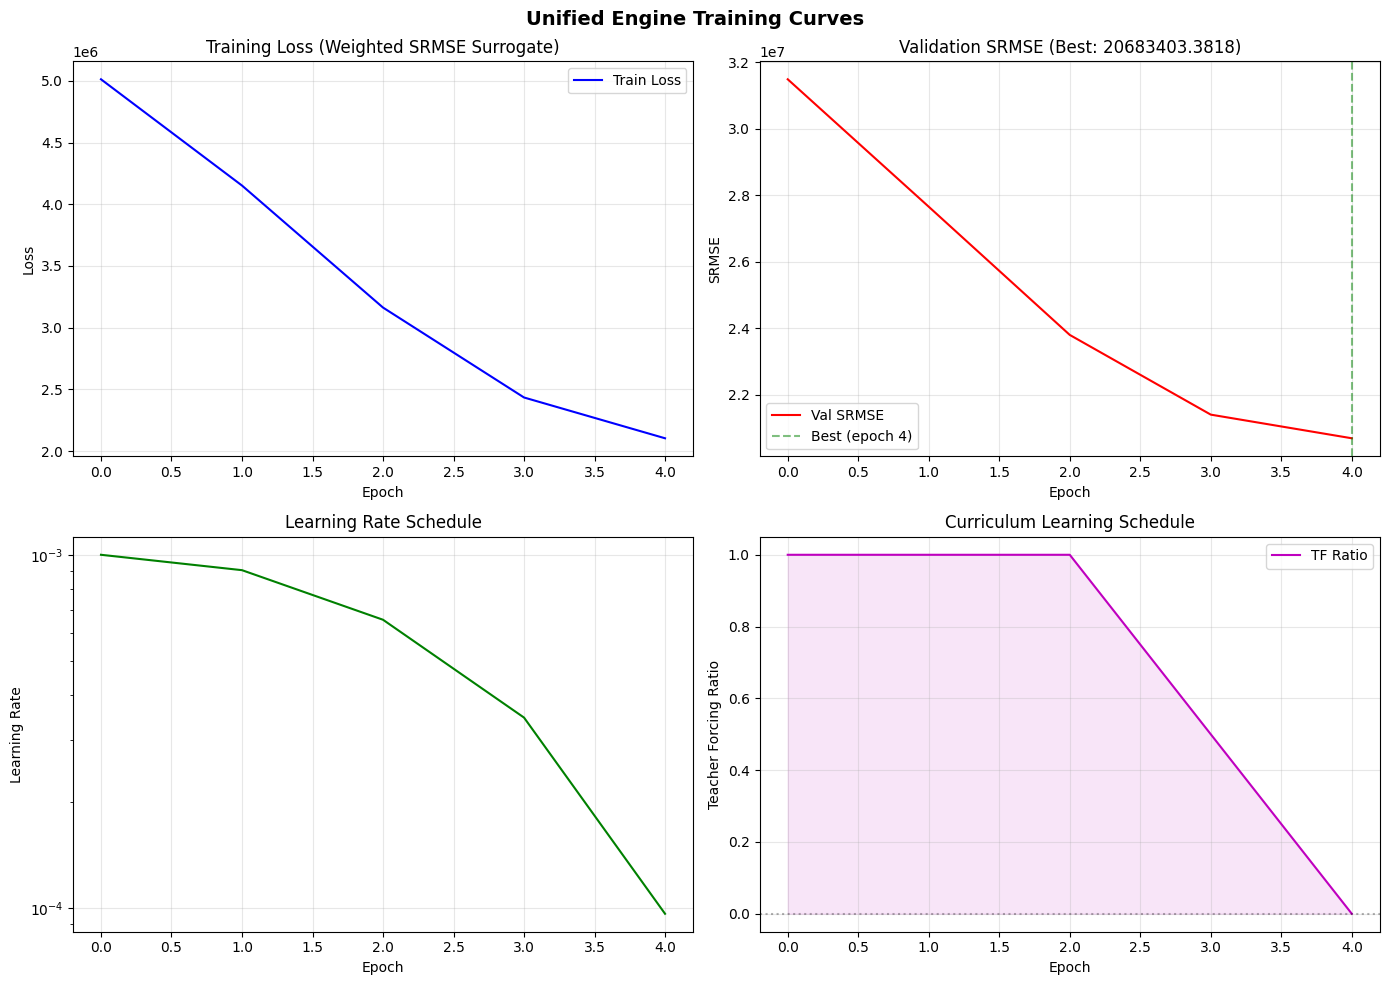

Training Summary (5 epochs, 178s total):
  Best val SRMSE : 20683403.381836 (epoch 4)
  Final train loss: 2103866.944030
  Final val SRMSE : 20683403.381836
  Avg epoch time  : 35.6s



In [8]:
# ── Cell 8: Plot Training Curves ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Unified Engine Training Curves", fontsize=14, fontweight="bold")

epochs = range(len(history.train_loss))

# Training Loss
axes[0, 0].plot(epochs, history.train_loss, 'b-', linewidth=1.5, label="Train Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Training Loss (Weighted SRMSE Surrogate)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation SRMSE
axes[0, 1].plot(epochs, history.val_srmse, 'r-', linewidth=1.5, label="Val SRMSE")
best_epoch = history.best_epoch
if best_epoch < len(history.val_srmse):
    best_idx = best_epoch - (epochs[0] if epochs else 0)
    if 0 <= best_idx < len(history.val_srmse):
        axes[0, 1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f"Best (epoch {best_epoch})")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("SRMSE")
axes[0, 1].set_title(f"Validation SRMSE (Best: {history.best_val_srmse:.4f})")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 0].plot(epochs, history.lr_history, 'g-', linewidth=1.5)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Learning Rate")
axes[1, 0].set_title("Learning Rate Schedule")
axes[1, 0].set_yscale("log")
axes[1, 0].grid(True, alpha=0.3)

# Teacher Forcing Ratio
ax_tf = axes[1, 1]
ax_tf.plot(epochs, history.tf_ratio, 'm-', linewidth=1.5, label="TF Ratio")
ax_tf.fill_between(epochs, 0, history.tf_ratio, alpha=0.1, color='m')
ax_tf.set_xlabel("Epoch")
ax_tf.set_ylabel("Teacher Forcing Ratio")
ax_tf.set_title("Curriculum Learning Schedule")
ax_tf.set_ylim(-0.05, 1.05)
ax_tf.axhline(y=0, color='k', linestyle=':', alpha=0.3)
ax_tf.legend()
ax_tf.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("logs/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(history.summary_str())

## 6. Validation with Full Competition Protocol

Run the `ValidationRunner` with exact competition scoring hierarchy.

In [9]:
# ── Cell 9: Full Validation ─────────────────────────────────────────
from src.validate import ValidationRunner

# Load best model
try:
    trainer.load_best()
    print("Loaded best checkpoint.")
except FileNotFoundError:
    print("No best checkpoint found — using current model.")

runner = ValidationRunner(
    model=trainer.model,
    data_root=str(RAW_DATA_PATH),
    device=DEVICE,
    model_ids=["1"],
    spinup_steps=10,
    run_diagnostics=True,
    verbose=True,
)

val_result = runner.validate_holdout(val_event_id="4")
print(val_result.summary_str())

Loaded best model from checkpoints\best_model.pt
Loaded best checkpoint.
FloodDataset (train) — 137 events across 2 model(s):
  Model_1: 68 events
  Model_2: 69 events

  Validating Model_1, Event 4 (1 event(s))...


C:\Users\Jian Wen Lee\UrbanFloodBench\src\graph_builder_unified.py:480: UserWarning: 2D static features: 24 NaN values → 0.
  warnings.warn(f"2D static features: {nan_count} NaN values → 0.")


    Event 4: 1D=41364216.0000, 2D=2590.7637, combined=20683403.3818 (5.4s)
  VALIDATION RESULTS
  Overall SRMSE: 20683403.381836
  Time: 63.8s

  Model 1:
    Event 4: 1d=41364216.0000, 2d=2590.7637  -> 20683403.3818
    --- Model 1 avg: 20683403.3818


C:\Users\Jian Wen Lee\UrbanFloodBench\src\graph_builder_unified.py:480: UserWarning: 2D static features: 24 NaN values → 0.
  warnings.warn(f"2D static features: {nan_count} NaN values → 0.")


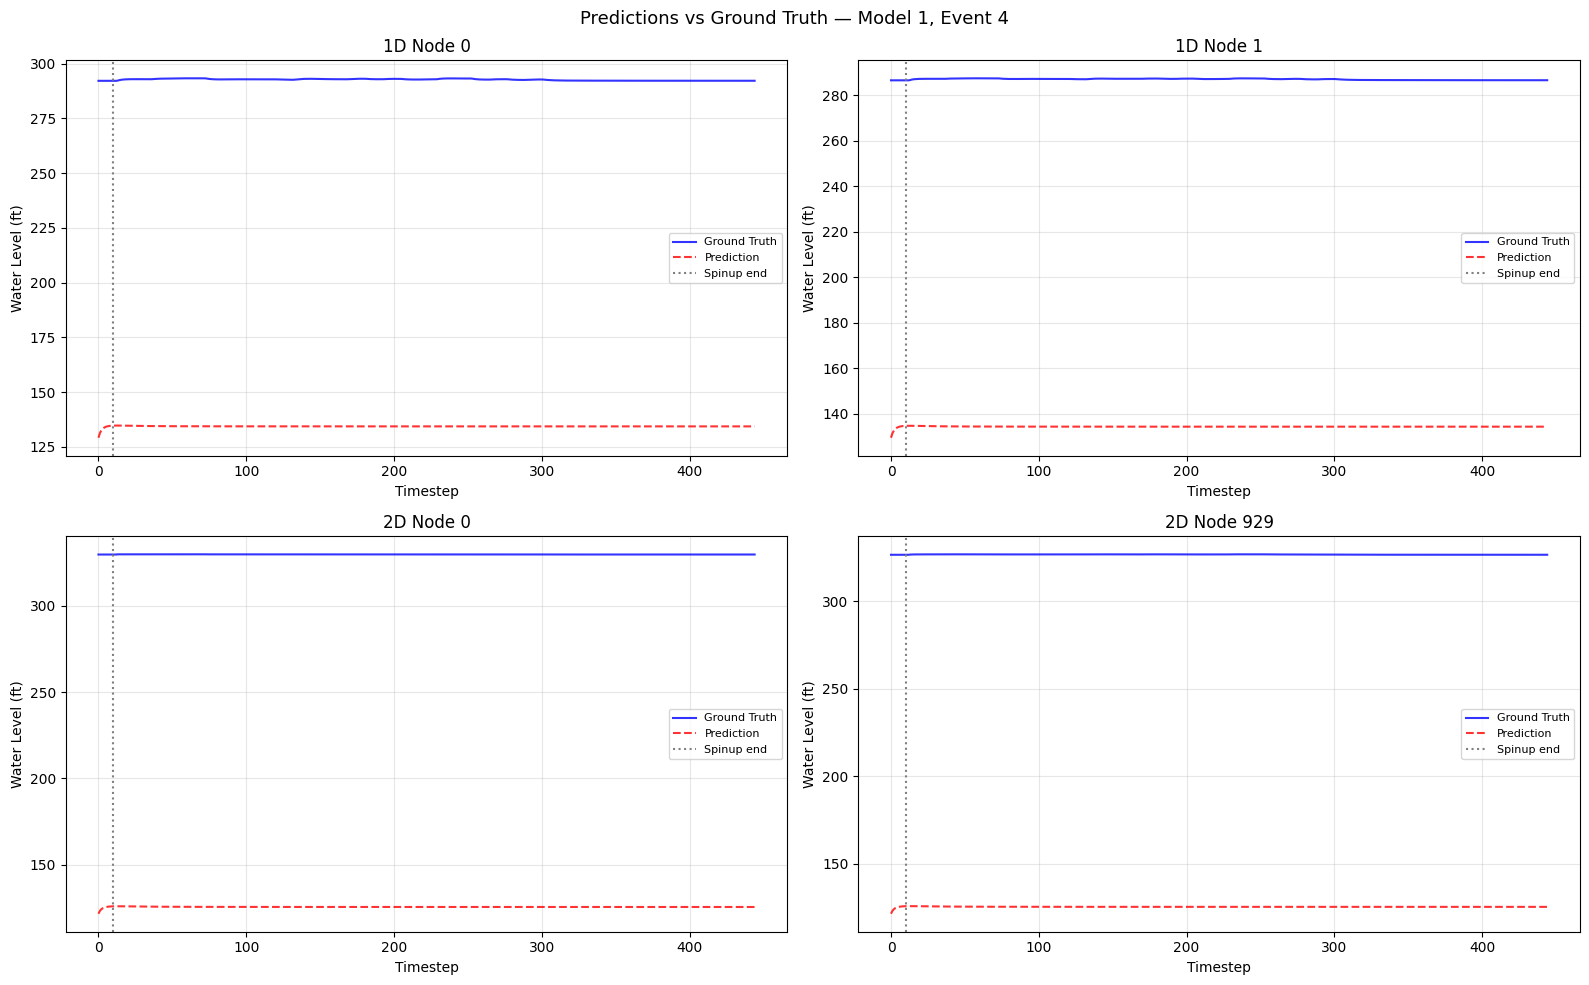

In [10]:
# ── Cell 10: Visualise Predictions vs Ground Truth ──────────────────
from src.validate import extract_predictions

# Get predictions for a validation event
val_ds = ds.filter_by_model("1")
val_sample = None
for i in range(len(val_ds)):
    s = val_ds[i]
    if s["event_id"] == "4":
        val_sample = s
        break

if val_sample is not None:
    val_graph = build_unified_graph(val_sample)
    pred_data = extract_predictions(trainer.model, val_graph, DEVICE)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Predictions vs Ground Truth — Model {val_sample['model_id']}, "
                 f"Event {val_sample['event_id']}", fontsize=13)

    skip = pred_data["spinup_steps"]

    # 1D: first 4 nodes
    n_show = min(4, pred_data["preds_1d"].shape[1])
    for i in range(min(2, n_show)):
        ax = axes[0, i]
        ax.plot(pred_data["targets_1d"][:, i].numpy(), 'b-', label="Ground Truth", alpha=0.8)
        ax.plot(pred_data["preds_1d"][:, i].numpy(), 'r--', label="Prediction", alpha=0.8)
        ax.axvline(x=skip, color='gray', linestyle=':', label="Spinup end")
        ax.set_title(f"1D Node {i}")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Water Level (ft)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # 2D: sample nodes
    n_2d = pred_data["preds_2d"].shape[1]
    sample_2d_nodes = [0, n_2d // 4] if n_2d > 1 else [0]
    for i, node_idx in enumerate(sample_2d_nodes[:2]):
        ax = axes[1, i]
        ax.plot(pred_data["targets_2d"][:, node_idx].numpy(), 'b-', label="Ground Truth", alpha=0.8)
        ax.plot(pred_data["preds_2d"][:, node_idx].numpy(), 'r--', label="Prediction", alpha=0.8)
        ax.axvline(x=skip, color='gray', linestyle=':', label="Spinup end")
        ax.set_title(f"2D Node {node_idx}")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Water Level (ft)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("logs/prediction_vs_truth.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Validation event not found.")

## 7. Submission Generation (v7 — UnifiedHeteroModel)

Generate the competition submission CSV from the v7-trained checkpoints.

**How it works:**
1. Load per-model checkpoint (`unified_model_{1,2}_best_val.pt` preferred; falls back to `unified_model_{1,2}.pt`) which contains model weights + `norm_stats`
2. For each test event, build a HeteroData graph using `build_hetero_graph` with the saved norm_stats
3. Run full autoregressive rollout (matching `_validate_one_event` exactly):
   - 10-step spinup with ground-truth features
   - Per-node 1D depth normalization for AR feedback
   - Delta-prediction with hard clamp (±5.0 1D, ±2.0 2D) × const_mask
   - Depth lags (t-2, t-3, t-4) replaced from predicted history
4. Convert `pred_depth + elevation → WSE` for submission
5. Format: per-event, **1D rows then 2D rows**, concatenated across events

In [4]:
# ── Cell 11: v7 Submission Generator ────────────────────────────────
# Loads UnifiedHeteroModel checkpoints trained by src.train_unified (v7)
# and runs full AR inference on test events to produce submission.csv.

import time
import warnings
from typing import Dict, List, Tuple, Any, Optional
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import Tensor

# ── Imports from the v7 pipeline ────────────────────────────────────
from src.dataset import FloodDataset
from src.graph_builder_unified import (
    build_hetero_graph,
    get_feature_dims,
    DEPTH_IDX, WATER_VOL_IDX, LAG1_IDX, LAG2_IDX, LAG3_IDX,
)
from src.model_unified import UnifiedHeteroModel
from src.train_unified import compute_model_stats

# ── Config ──────────────────────────────────────────────────────────
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
MODEL_IDS = ["1", "2"]
SPINUP = 10
DELTA_CLAMP_2D = 2.0
DELTA_CLAMP_1D = 5.0

print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Models         : {MODEL_IDS}")
print(f"Spinup         : {SPINUP}")
print(f"Delta clamp    : 1D=±{DELTA_CLAMP_1D}, 2D=±{DELTA_CLAMP_2D}")


# =====================================================================
#  AR Inference (mirrors _validate_one_event from train_unified.py)
# =====================================================================

@torch.no_grad()
def predict_event_v7(
    model: UnifiedHeteroModel,
    graph: Any,
    norm_stats: Dict,
    stds_1d: Tensor,
    stds_2d: Tensor,
    device: torch.device,
    spinup: int = 10,
    delta_clamp: float = 2.0,
    delta_clamp_1d: float = 5.0,
) -> Tuple[Tensor, Tensor]:
    """Full AR inference on one event → (pred_wse_1d, pred_wse_2d).

    Returns [T_scored, N_1d] and [T_scored, N_2d] tensors of
    absolute water surface elevation (WSE) for the scored period
    (after spinup).
    """
    graph = graph.to(device)
    model.eval()

    T = graph.num_timesteps
    n_1d = graph["1d"].num_nodes
    n_2d = graph["2d"].num_nodes
    spinup = min(spinup, T - 1)

    # Edge indices
    edge_index_dict = {}
    for et in graph.edge_types:
        edge_index_dict[et] = graph[et].edge_index

    # 2D global depth norm stats
    d2_mean = norm_stats["2d"]["depth"]["mean"]
    d2_std = norm_stats["2d"]["depth"]["std"]

    # Per-node 1D depth stats
    if "depth_per_node_mean" in norm_stats["1d"]:
        _pn_mean_1d = torch.tensor(
            norm_stats["1d"]["depth_per_node_mean"], dtype=torch.float32
        ).to(device)
        _pn_std_1d = torch.tensor(
            norm_stats["1d"]["depth_per_node_std"], dtype=torch.float32
        ).to(device)
    else:
        d1_mean = norm_stats["1d"]["depth"]["mean"]
        d1_std = norm_stats["1d"]["depth"]["std"]
        _pn_mean_1d = torch.full((n_1d,), d1_mean, device=device)
        _pn_std_1d = torch.full((n_1d,), max(d1_std, 1e-4), device=device)

    # Constant-node masks
    const_mask_1d = (stds_1d.to(device) >= 0.01).float()
    const_mask_2d = (stds_2d.to(device) >= 0.01).float()

    # ── Spinup: warm GRU hidden states with GT features ──────────
    hidden = model.init_hidden(n_1d, n_2d, device)
    for t in range(spinup):
        x_dict = {
            "1d": graph["1d"].x[t].to(device),
            "2d": graph["2d"].x[t].to(device),
        }
        _, hidden = model(x_dict, edge_index_dict, hidden)

    # ── Prediction phase (fully autoregressive) ──────────────────
    prev_depth_1d = graph["1d"].depth[spinup - 1].to(device)
    prev_depth_2d = graph["2d"].depth[spinup - 1].to(device)

    # Build depth history for lag replacement
    _hist_1d, _hist_2d = [], []
    for _t in range(max(0, spinup - 4), spinup):
        _hist_1d.append(graph["1d"].depth[_t].to(device))
        _hist_2d.append(graph["2d"].depth[_t].to(device))
    while len(_hist_1d) < 4:
        _hist_1d.insert(0, _hist_1d[0].clone())
        _hist_2d.insert(0, _hist_2d[0].clone())

    def _get_lag(hist, n):
        idx = len(hist) - n
        return hist[max(0, idx)]

    all_pred_wse_1d = []
    all_pred_wse_2d = []

    for t in range(spinup, T):
        x_1d_t = graph["1d"].x[t].clone().to(device)
        x_2d_t = graph["2d"].x[t].clone().to(device)

        # Replace depth + lag features with AR predictions
        x_1d_t[:, DEPTH_IDX] = (prev_depth_1d - _pn_mean_1d) / _pn_std_1d
        x_2d_t[:, DEPTH_IDX] = (prev_depth_2d - d2_mean) / max(d2_std, 1e-8)
        # Index 5 during AR: effective_depth (P0) or water_volume (pre-P0 checkpoint compat)
        if x_2d_t.size(-1) > WATER_VOL_IDX:
            if "effective_depth" in norm_stats["2d"]:
                st = norm_stats["2d"]["effective_depth"]
                x_2d_t[:, WATER_VOL_IDX] = (prev_depth_2d - st["mean"]) / max(st["std"], 1e-8)
            elif hasattr(graph["2d"], "area"):
                st = norm_stats["2d"].get("water_volume", {"mean": 0.0, "std": 1.0})
                vol_proxy = prev_depth_2d * graph["2d"].area.to(device)
                x_2d_t[:, WATER_VOL_IDX] = (vol_proxy - st["mean"]) / max(st["std"], 1e-8)
        x_1d_t[:, LAG1_IDX] = (_get_lag(_hist_1d, 2) - _pn_mean_1d) / _pn_std_1d
        x_1d_t[:, LAG2_IDX] = (_get_lag(_hist_1d, 3) - _pn_mean_1d) / _pn_std_1d
        x_1d_t[:, LAG3_IDX] = (_get_lag(_hist_1d, 4) - _pn_mean_1d) / _pn_std_1d
        x_2d_t[:, LAG1_IDX] = (_get_lag(_hist_2d, 2) - d2_mean) / max(d2_std, 1e-8)
        x_2d_t[:, LAG2_IDX] = (_get_lag(_hist_2d, 3) - d2_mean) / max(d2_std, 1e-8)
        x_2d_t[:, LAG3_IDX] = (_get_lag(_hist_2d, 4) - d2_mean) / max(d2_std, 1e-8)

        x_dict = {"1d": x_1d_t, "2d": x_2d_t}
        delta_dict, hidden = model(x_dict, edge_index_dict, hidden)

        raw_delta_1d = delta_dict["1d"].clamp(-delta_clamp_1d, delta_clamp_1d) * const_mask_1d
        raw_delta_2d = delta_dict["2d"].clamp(-delta_clamp, delta_clamp) * const_mask_2d

        pred_depth_1d = prev_depth_1d + raw_delta_1d
        pred_depth_2d = prev_depth_2d + raw_delta_2d

        # WSE = depth + elevation reference
        pred_wse_1d = pred_depth_1d + graph["1d"].elev.to(device)
        pred_wse_2d = pred_depth_2d + graph["2d"].elev.to(device)

        all_pred_wse_1d.append(pred_wse_1d)
        all_pred_wse_2d.append(pred_wse_2d)

        # Update history
        _hist_1d.append(prev_depth_1d)
        _hist_2d.append(prev_depth_2d)
        prev_depth_1d = pred_depth_1d
        prev_depth_2d = pred_depth_2d

        if torch.isnan(pred_depth_1d).any() or torch.isnan(pred_depth_2d).any():
            warnings.warn(f"NaN at t={t} — truncating.")
            break

    preds_1d = torch.stack(all_pred_wse_1d)  # [T_scored, N_1d]
    preds_2d = torch.stack(all_pred_wse_2d)  # [T_scored, N_2d]
    return preds_1d, preds_2d


# =====================================================================
#  Build submission rows (vectorized)
# =====================================================================

def build_rows(preds: Tensor, model_id: str, event_id: str,
               node_type: int, spinup: int) -> pd.DataFrame:
    """Convert [T_scored, N] WSE predictions to long-format rows.

    Row ordering: node-major (all timesteps for node 0, then node 1, ...).
    node_type: integer 1 (1D) or 2 (2D).
    row_id is a placeholder — replaced with sequential ints at the end.
    """
    preds_np = preds.cpu().numpy()
    T_scored, N = preds_np.shape

    # NaN forward-fill
    nan_mask = np.isnan(preds_np)
    if nan_mask.any():
        for t_idx in range(1, T_scored):
            fill = nan_mask[t_idx]
            preds_np[t_idx, fill] = preds_np[t_idx - 1, fill]
        preds_np = np.nan_to_num(preds_np, nan=0.0)

    # Node-major ordering: iterate nodes first, timesteps second
    preds_node_major = preds_np.T  # [N, T_scored]
    wl_flat = preds_node_major.ravel()

    node_ids = np.arange(N)
    n_flat = np.repeat(node_ids, T_scored)

    return pd.DataFrame({
        "row_id": 0,  # placeholder, replaced after concat
        "model_id": int(model_id),
        "event_id": int(event_id),
        "node_type": int(node_type),
        "node_id": n_flat.astype(int),
        "water_level": wl_flat.astype(np.float64),
    })


# =====================================================================
#  Main Generation Loop
# =====================================================================

t_start = time.time()
test_ds = FloodDataset(str(RAW_DATA_PATH), mode="test")
train_ds = FloodDataset(str(RAW_DATA_PATH), mode="train")

print(f"\nTest events: {len(test_ds)}")

all_dfs = []

for mid in MODEL_IDS:
    # Both models: prefer best EMA checkpoint
    ckpt_path = CHECKPOINT_DIR / f"unified_model_{mid}.pt"  # EMA
    if not ckpt_path.exists():
        ckpt_path = CHECKPOINT_DIR / f"unified_model_{mid}_best_val.pt"
    if not ckpt_path.exists():
        print(f"  [SKIP] {ckpt_path} not found")
        continue

    print(f"\n{'='*50}")
    print(f"  Model {mid}: loading {ckpt_path.name}")

    # ── Load checkpoint ──────────────────────────────────────────
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    norm_stats = ckpt["norm_stats"]

    model = UnifiedHeteroModel(
        in_channels_1d=ckpt["in_channels_1d"],
        in_channels_2d=ckpt["in_channels_2d"],
        hidden_channels=ckpt["hidden_channels"],
        num_gnn_layers=ckpt["num_gnn_layers"],
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"  Loaded epoch {ckpt['epoch']}, val SRMSE = {ckpt['val_srmse']:.4f}")

    # ── Compute per-node stds from training data (for const masks) ─
    node_stds = train_ds.compute_node_stds(model_id=mid)
    stds_1d = torch.tensor(node_stds[mid]["1d"], dtype=torch.float32)
    stds_2d = torch.tensor(node_stds[mid]["2d"], dtype=torch.float32)
    print(f"  Node stds: 1D={len(stds_1d)}, 2D={len(stds_2d)}")

    # ── Run inference on test events for this model ──────────────
    test_events = test_ds.filter_by_model(mid)
    print(f"  Test events for Model {mid}: {len(test_events)}")

    for idx in range(len(test_events)):
        sample = test_events[idx]
        event_id = sample["event_id"]

        try:
            graph = build_hetero_graph(sample, norm_stats)

            # Compatibility: pad graph features if checkpoint needs more, or slice if checkpoint needs fewer
            need_1d = ckpt["in_channels_1d"] - graph["1d"].x.size(-1)
            need_2d = ckpt["in_channels_2d"] - graph["2d"].x.size(-1)
            if need_1d > 0:
                pad = torch.zeros(graph["1d"].x.shape[0], graph["1d"].x.shape[1], need_1d, dtype=graph["1d"].x.dtype, device=graph["1d"].x.device)
                graph["1d"].x = torch.cat([graph["1d"].x, pad], dim=-1)
            elif need_1d < 0:
                graph["1d"].x = graph["1d"].x[..., :ckpt["in_channels_1d"]]

            if need_2d > 0:
                pad = torch.zeros(graph["2d"].x.shape[0], graph["2d"].x.shape[1], need_2d, dtype=graph["2d"].x.dtype, device=graph["2d"].x.device)
                graph["2d"].x = torch.cat([graph["2d"].x, pad], dim=-1)
            elif need_2d < 0:
                graph["2d"].x = graph["2d"].x[..., :ckpt["in_channels_2d"]]

            preds_1d, preds_2d = predict_event_v7(
                model, graph, norm_stats, stds_1d, stds_2d,
                DEVICE, spinup=SPINUP,
                delta_clamp=DELTA_CLAMP_2D, delta_clamp_1d=DELTA_CLAMP_1D,
            )

            df_1d = build_rows(preds_1d, mid, event_id, 1, SPINUP)
            df_2d = build_rows(preds_2d, mid, event_id, 2, SPINUP)
            all_dfs.append(df_1d)
            all_dfs.append(df_2d)

            print(f"    Event {event_id}: 1D={preds_1d.shape}, 2D={preds_2d.shape}")

        except Exception as e:
            warnings.warn(f"  Failed Model_{mid} Event_{event_id}: {e}")
            import traceback; traceback.print_exc()
            continue

# ── Merge & save ─────────────────────────────────────────────────
submission = pd.concat(all_dfs, ignore_index=True)

# Assign sequential integer row_ids (matching competition format)
submission["row_id"] = np.arange(len(submission), dtype=np.int64)

# Sanity checks
nan_count = submission["water_level"].isna().sum()
print(f"\n{'='*50}")
print(f"  Submission shape   : {submission.shape}")
print(f"  NaN water_level    : {nan_count}")
print(f"  row_id range       : [{submission['row_id'].min()}, {submission['row_id'].max()}]")
print(f"  Models             : {sorted(submission['model_id'].unique())}")
print(f"  Events             : {sorted(submission['event_id'].unique())}")
print(f"  node_type values   : {sorted(submission['node_type'].unique())}")
print(f"  Water level range  : [{submission['water_level'].min():.2f}, "
      f"{submission['water_level'].max():.2f}]")

# Column order per competition spec
submission = submission[["row_id", "model_id", "event_id",
                         "node_type", "node_id", "water_level"]]

out_path = PROJECT_ROOT / "submission.csv"
submission.to_csv(out_path, index=False)
elapsed = time.time() - t_start
print(f"\n  Saved to {out_path} ({submission.shape[0]:,} rows)")
print(f"  Time: {elapsed:.1f}s")

submission.head(20)

Checkpoint dir : C:\Users\Jian Wen Lee\UrbanFloodBench\checkpoints
Models         : ['1', '2']
Spinup         : 10
Delta clamp    : 1D=±5.0, 2D=±2.0
FloodDataset (test) — 59 events across 2 model(s):
  Model_1: 29 events
  Model_2: 30 events
FloodDataset (train) — 137 events across 2 model(s):
  Model_1: 68 events
  Model_2: 69 events

Test events: 59

  Model 1: loading unified_model_1.pt
  Loaded epoch 77, val SRMSE = 0.3780
  Node stds: 1D=17, 2D=3716
  Test events for Model 1: 29
    Event 18: 1D=torch.Size([36, 17]), 2D=torch.Size([36, 3716])
    Event 22: 1D=torch.Size([39, 17]), 2D=torch.Size([39, 3716])
    Event 26: 1D=torch.Size([36, 17]), 2D=torch.Size([36, 3716])
    Event 29: 1D=torch.Size([39, 17]), 2D=torch.Size([39, 3716])
    Event 31: 1D=torch.Size([39, 17]), 2D=torch.Size([39, 3716])
    Event 33: 1D=torch.Size([147, 17]), 2D=torch.Size([147, 3716])
    Event 35: 1D=torch.Size([387, 17]), 2D=torch.Size([387, 3716])
    Event 37: 1D=torch.Size([39, 17]), 2D=torch.Size

,row_id,model_id,event_id,node_type,node_id,water_level
0,0,1,18,1,0,295.140991
1,1,1,18,1,0,295.124115
2,2,1,18,1,0,295.068848
3,3,1,18,1,0,295.170532
4,4,1,18,1,0,295.367096
5,5,1,18,1,0,295.429962
6,6,1,18,1,0,295.451874
7,7,1,18,1,0,295.464142
8,8,1,18,1,0,295.474792
9,9,1,18,1,0,295.501434


---

## Scaling Up: Full Training Configuration

Once the pipeline is verified, use this config for the real training run:

In [ ]:
# ── Cell 12: Production Training Config (DO NOT RUN IN NOTEBOOK) ───
# Copy this to a .py script or CLI command for real training.
# Running 60+ epochs in a notebook is not recommended.

production_cfg = {
    "data_root": str(RAW_DATA_PATH),
    "model_ids": ["1", "2"],
    "val_event_id": "4",
    
    "hidden_channels": 128,
    "num_gnn_layers": 3,
    "num_gru_layers": 2,
    "dropout": 0.1,
    
    "epochs": 60,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "grad_clip_norm": 1.0,
    
    "tf_warmup_epochs": 10,
    "tf_decay_epochs": 30,
    "tf_min_ratio": 0.0,
    
    "pushforward_K": 10,
    "use_push_forward": True,
    "temporal_scheme": "linear",
    
    "scheduler": "cosine",
    "early_stop_patience": 15,
    
    "use_amp": True,
    "device": "auto",
}

print("Production training config:")
print(json.dumps(production_cfg, indent=2))
print("\nTo run: python -m src.trainer --epochs 60 --hidden_channels 128")